=== DATA SETUP ===
Loaded lifted states shape: (1100, 38)
Total time steps: 1100
Total lifted dimensions: 38

=== TRAIN / FORECAST SPLIT ===
Z_train shape: (1000, 38)
Z1_train shape: (999, 38)
Z2_train shape: (999, 38)
Z_future_true shape: (100, 38)

=== KOOPMAN TRAINING ===
Koopman operator K shape: (38, 38)

=== FORECASTING ===
Z_forecast shape: (100, 38)
Forecasted time indices:
From raw index 1000 to 1099

=== ERROR SUMMARY FOR NEXT 100 FORECASTED STEPS ===
a:
  RMSE = 6.225813e+02
  MAE  = 4.996733e+02
e:
  RMSE = 1.916637e-04
  MAE  = 1.607286e-04
i:
  RMSE = 5.189938e-05
  MAE  = 4.418234e-05
omega:
  RMSE = 1.823838e+00
  MAE  = 1.799590e+00
raan:
  RMSE = 1.812269e+00
  MAE  = 1.805139e+00
v:
  RMSE = 1.038909e+00
  MAE  = 7.900864e-01

=== KOOPMAN SPECTRUM ANALYSIS ===
Total Eigenvalues: 38
Max Eigenvalue: 1.00104 + 0.00000j
Max Eigenvalue Magnitude: 1.00104


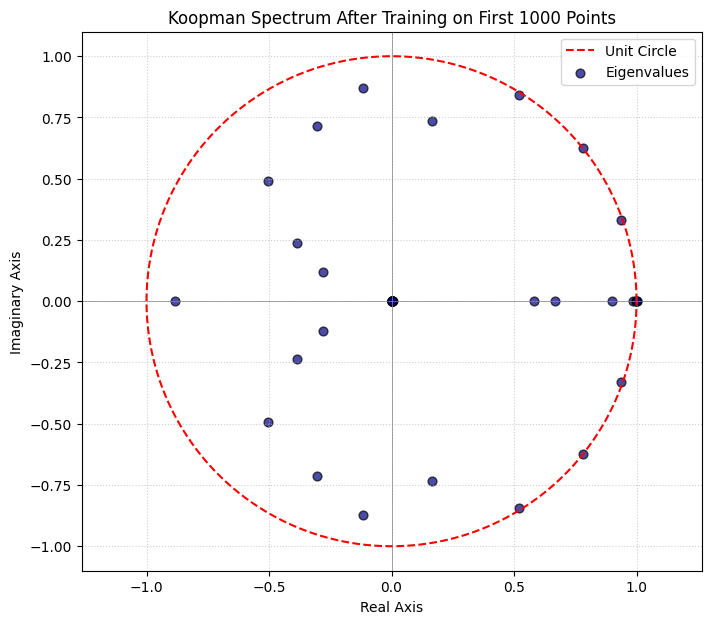

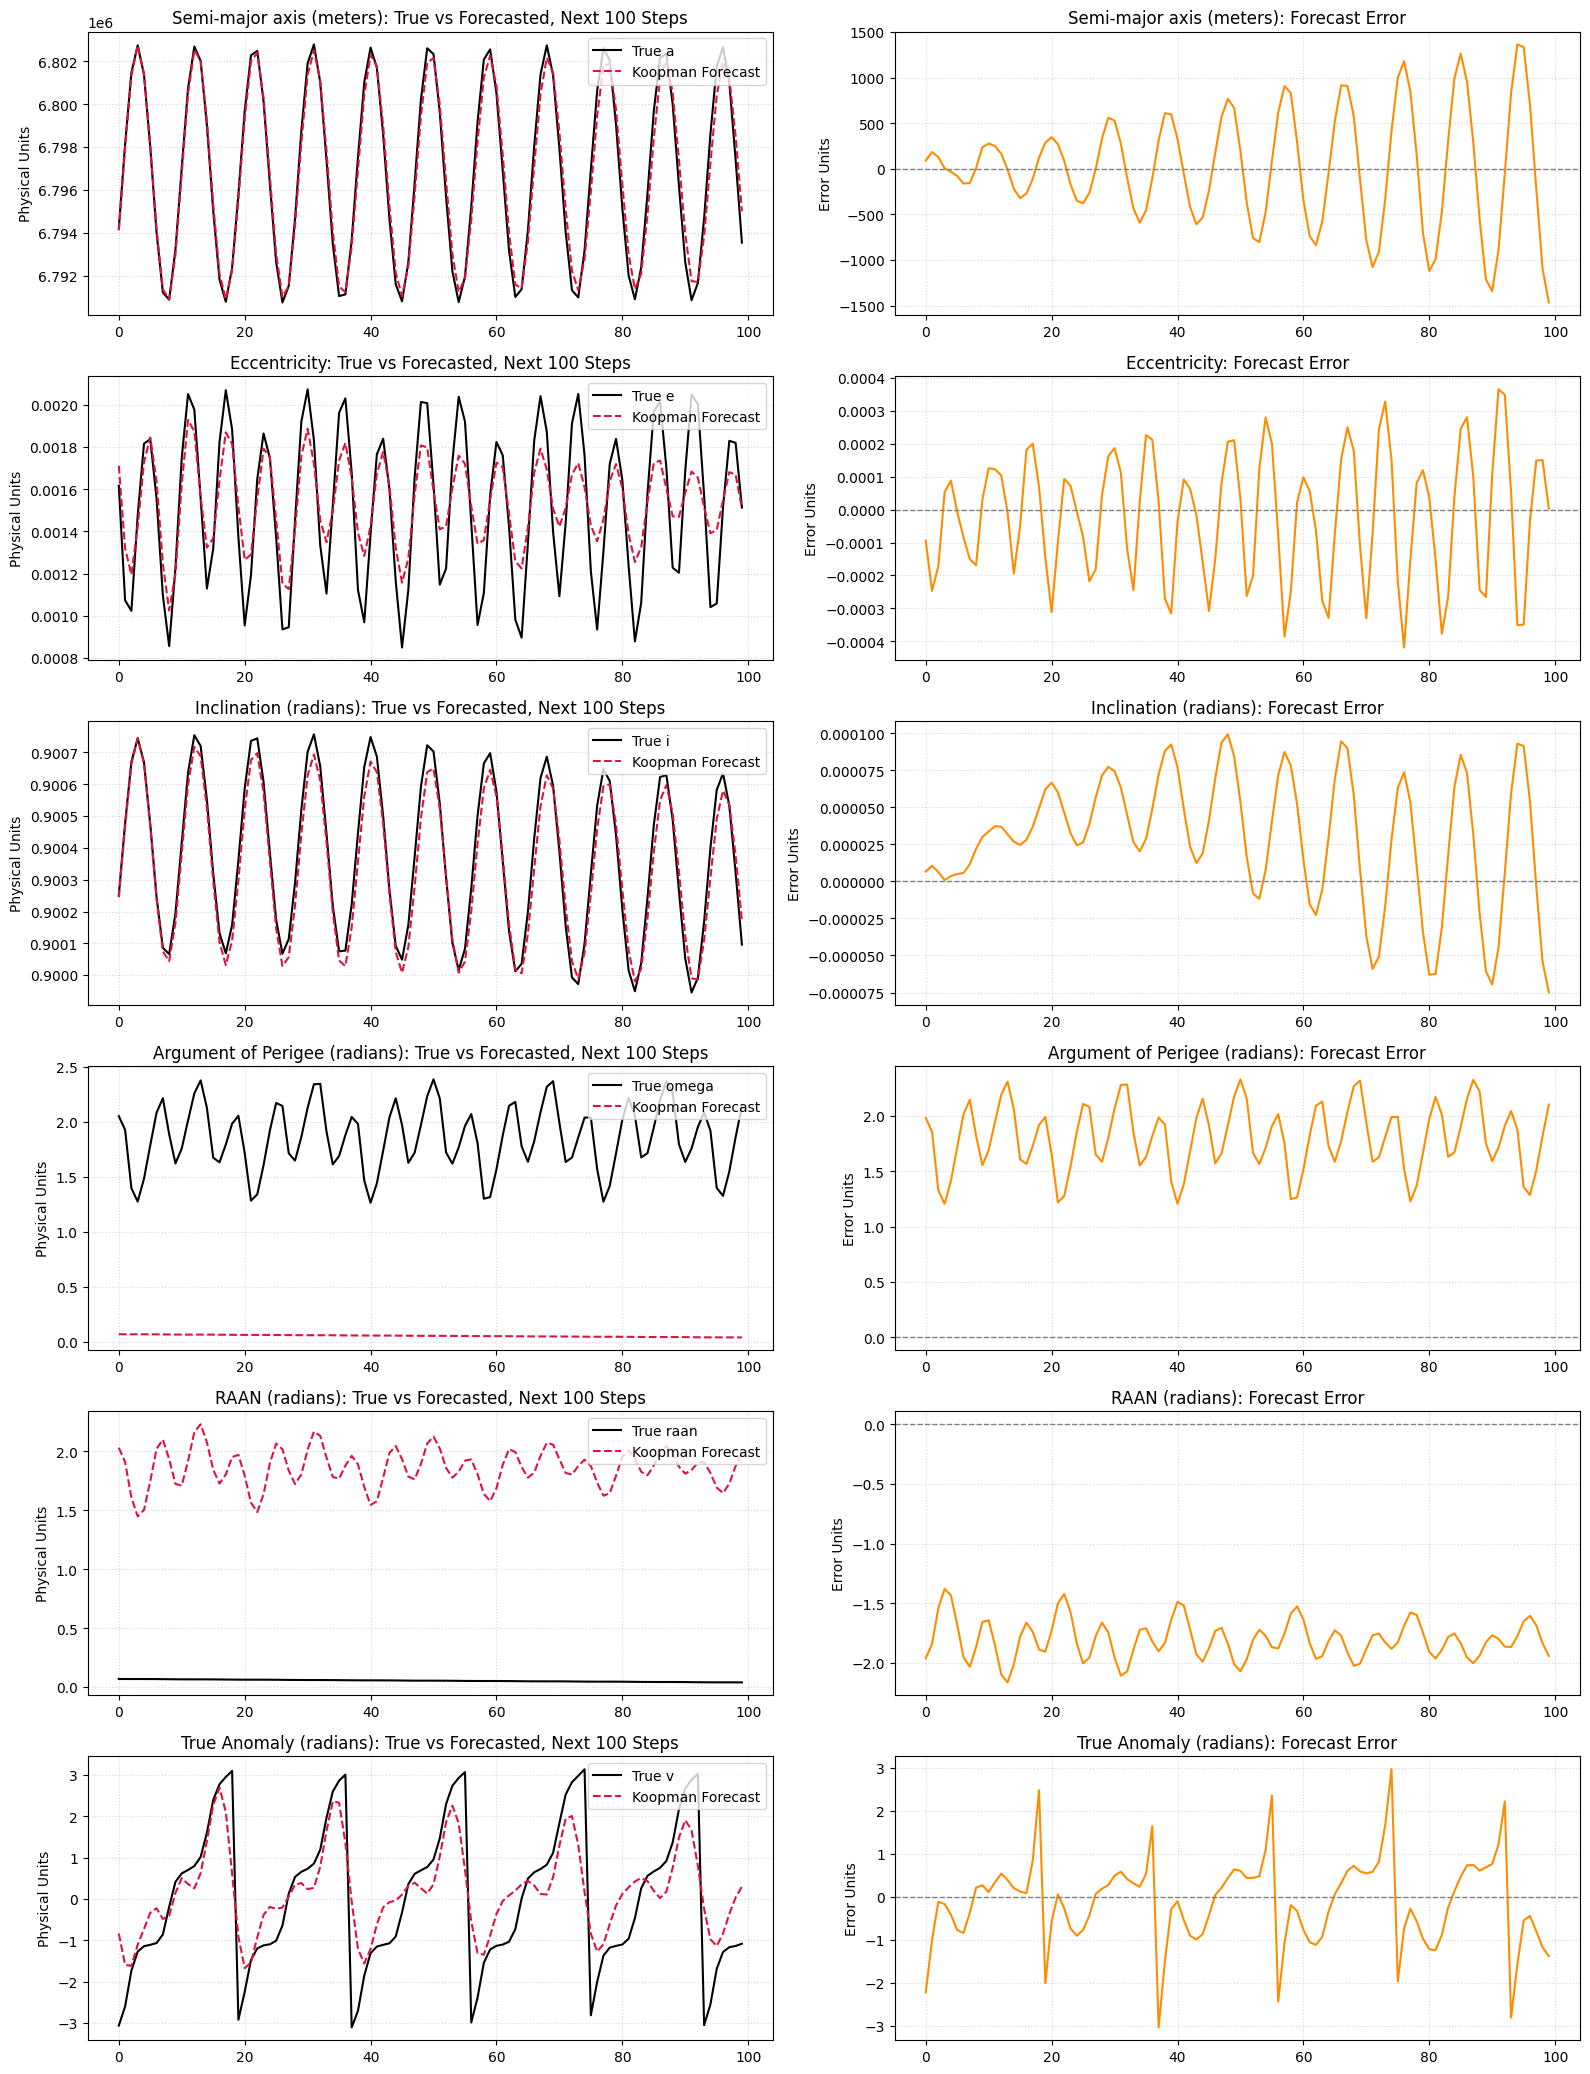

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler

# ==============================================================================
# 1. DATA LOADING
# ==============================================================================

try:
    df_raw = pd.read_csv("raw_orbit_data.csv")
    df_lifted = pd.read_csv("lifted_orbit_data.csv")
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"Missing data file: {e}. Ensure both 'raw_orbit_data.csv' and "
        "'lifted_orbit_data.csv' are in your working directory."
    )

Z = df_lifted.values
n_samples, n_dim = Z.shape

print("=== DATA SETUP ===")
print(f"Loaded lifted states shape: {Z.shape}")
print(f"Total time steps: {n_samples}")
print(f"Total lifted dimensions: {n_dim}\n")


# ==============================================================================
# 2. SETTINGS: TRAIN FIRST 1000, PREDICT NEXT 100
# ==============================================================================

N_train = 1000
N_forecast = 100

if n_samples < N_train + N_forecast:
    raise ValueError(
        f"Not enough data. You need at least {N_train + N_forecast} samples, "
        f"but you only have {n_samples}."
    )


# ==============================================================================
# 3. SCALER FOR INVERSE TRANSFORM
# ==============================================================================

# IMPORTANT:
# This scaler must be fitted in the SAME WAY as in your lifting code.
# If your lifting code used all raw data, use df_raw[['a', 'e']].
# If your lifting code used only training data, use df_raw.iloc[:N_train][['a', 'e']].

scaler_ae = MinMaxScaler(feature_range=(-1, 1))
scaler_ae.fit(df_raw[['a', 'e']])

# For a cleaner train/test protocol, you may instead use:
# scaler_ae.fit(df_raw.iloc[:N_train][['a', 'e']])


# ==============================================================================
# 4. SPLIT DATA
# ==============================================================================

# First 1000 lifted states are used for EDMD training
Z_train = Z[:N_train]

# The next 100 lifted states are kept only for comparison
Z_future_true = Z[N_train:N_train + N_forecast]

# For EDMD, we need pairs:
# Z(k)     -> Z(k+1)
# Z1_train -> Z2_train

Z1_train = Z_train[:-1]
Z2_train = Z_train[1:]

print("=== TRAIN / FORECAST SPLIT ===")
print(f"Z_train shape: {Z_train.shape}")
print(f"Z1_train shape: {Z1_train.shape}")
print(f"Z2_train shape: {Z2_train.shape}")
print(f"Z_future_true shape: {Z_future_true.shape}\n")


# ==============================================================================
# 5. TRAIN KOOPMAN OPERATOR USING RIDGE EDMD
# ==============================================================================

model = Ridge(alpha=1e-7, fit_intercept=False)
model.fit(Z1_train, Z2_train)

K = model.coef_

print("=== KOOPMAN TRAINING ===")
print(f"Koopman operator K shape: {K.shape}\n")


# ==============================================================================
# 6. RECURSIVE FORECASTING FOR NEXT 100 STEPS
# ==============================================================================

# Start from the last known training state:
# This is Z at time index 999.
z_current = Z_train[-1].copy()

Z_forecast = []

for step in range(N_forecast):
    # Predict next lifted state:
    # z(k+1) = K z(k)
    # Because sklearn gives K as model.coef_,
    # row-vector form is: z_next = z_current @ K.T
    z_next = z_current @ K.T

    Z_forecast.append(z_next)

    # Use prediction as the next input
    z_current = z_next.copy()

Z_forecast = np.array(Z_forecast)

print("=== FORECASTING ===")
print(f"Z_forecast shape: {Z_forecast.shape}")
print("Forecasted time indices:")
print(f"From raw index {N_train} to {N_train + N_forecast - 1}\n")


# ==============================================================================
# 7. UNLIFT FORECASTED VALUES TO RAW ORBITAL ELEMENTS
# ==============================================================================

# True raw values for the future 100 steps
true_raw_future = df_raw.iloc[N_train:N_train + N_forecast].copy().reset_index(drop=True)

# Your convention:
# column 0 of lifted data is probably constant 1
# columns 1:7 are:
# ['a', 'e', 'i', 'omega', 'raan', 'v']

pred_raw_future = pd.DataFrame(
    Z_forecast[:, 1:7],
    columns=['a', 'e', 'i', 'omega', 'raan', 'v']
)

# Inverse transform a and e
pred_raw_future[['a', 'e']] = scaler_ae.inverse_transform(
    pred_raw_future[['a', 'e']]
)

angles = ['i', 'omega', 'raan', 'v']


# ==============================================================================
# 8. COMPUTE ERRORS
# ==============================================================================

errors = pd.DataFrame()

for col in ['a', 'e', 'i', 'omega', 'raan', 'v']:

    true_vals = true_raw_future[col].values
    pred_vals = pred_raw_future[col].values

    if col in angles:
        # Angle-aware error
        errors[col] = np.arctan2(
            np.sin(true_vals - pred_vals),
            np.cos(true_vals - pred_vals)
        )
    else:
        errors[col] = true_vals - pred_vals


print("=== ERROR SUMMARY FOR NEXT 100 FORECASTED STEPS ===")
for col in ['a', 'e', 'i', 'omega', 'raan', 'v']:
    rmse = np.sqrt(np.mean(errors[col].values ** 2))
    mae = np.mean(np.abs(errors[col].values))

    print(f"{col}:")
    print(f"  RMSE = {rmse:.6e}")
    print(f"  MAE  = {mae:.6e}")

print()


# ==============================================================================
# 9. OPTIONAL: KOOPMAN SPECTRUM
# ==============================================================================

eigvals, _ = np.linalg.eig(K)

magnitudes = np.abs(eigvals)
max_idx = np.argmax(magnitudes)
max_eigval = eigvals[max_idx]
max_magnitude = magnitudes[max_idx]

print("=== KOOPMAN SPECTRUM ANALYSIS ===")
print(f"Total Eigenvalues: {len(eigvals)}")
print(f"Max Eigenvalue: {max_eigval.real:.5f} + {max_eigval.imag:.5f}j")
print(f"Max Eigenvalue Magnitude: {max_magnitude:.5f}")

plt.figure(figsize=(8, 7))
theta = np.linspace(0, 2 * np.pi, 200)

plt.plot(
    np.cos(theta),
    np.sin(theta),
    'r--',
    linewidth=1.5,
    label='Unit Circle'
)

plt.scatter(
    eigvals.real,
    eigvals.imag,
    color='navy',
    alpha=0.7,
    edgecolors='k',
    s=40,
    label='Eigenvalues'
)

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

plt.title("Koopman Spectrum After Training on First 1000 Points")
plt.xlabel("Real Axis")
plt.ylabel("Imaginary Axis")
plt.axis("equal")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()


# ==============================================================================
# 10. PLOT TRUE VS FORECASTED NEXT 100 STEPS
# ==============================================================================

feature_names = {
    'a': 'Semi-major axis (meters)',
    'e': 'Eccentricity',
    'i': 'Inclination (radians)',
    'omega': 'Argument of Perigee (radians)',
    'raan': 'RAAN (radians)',
    'v': 'True Anomaly (radians)'
}

fig, axes = plt.subplots(
    len(feature_names),
    2,
    figsize=(16, 3.5 * len(feature_names))
)

for idx, col in enumerate(feature_names.keys()):

    name = feature_names[col]

    true_vals = true_raw_future[col].values
    pred_vals = pred_raw_future[col].values
    error_vals = errors[col].values

    # Left: True vs Forecasted
    ax_comp = axes[idx, 0]
    ax_comp.plot(
        true_vals,
        label=f"True {col}",
        color="black",
        linewidth=1.5
    )

    ax_comp.plot(
        pred_vals,
        "--",
        label="Koopman Forecast",
        color="crimson",
        linewidth=1.5
    )

    ax_comp.set_title(f"{name}: True vs Forecasted, Next 100 Steps")
    ax_comp.set_ylabel("Physical Units")
    ax_comp.grid(True, linestyle=":", alpha=0.5)
    ax_comp.legend(loc="upper right")

    # Right: Error
    ax_err = axes[idx, 1]
    ax_err.plot(
        error_vals,
        color="darkorange",
        linewidth=1.5
    )

    ax_err.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1
    )

    ax_err.set_title(f"{name}: Forecast Error")
    ax_err.set_ylabel("Error Units")
    ax_err.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

=== DATA SETUP ===
Loaded lifted states shape: (1100, 38)
Total time steps: 1100
Total lifted dimensions: 38

=== TRAIN / FORECAST SPLIT ===
Z_train shape: (1000, 38)
Z1_train shape: (999, 38)
Z2_train shape: (999, 38)
Z_future_true shape: (100, 38)

=== SVD-BASED KOOPMAN TRAINING ===
Original lifted dimension: 38
Number of singular values: 38
Largest singular value: 1.521130e+03
SVD tolerance: 1.521130e-07
Retained SVD rank: 31
Koopman operator K shape: (38, 38)

=== FORECASTING ===
Z_forecast shape: (100, 38)
Forecasted time indices:
From raw index 1000 to 1099

=== ERROR SUMMARY FOR NEXT 100 FORECASTED STEPS ===
a:
  RMSE = 3.556476e+02
  MAE  = 2.720189e+02
e:
  RMSE = 1.828787e-04
  MAE  = 1.519381e-04
i:
  RMSE = 3.490356e-05
  MAE  = 2.828263e-05
omega:
  RMSE = 1.823707e+00
  MAE  = 1.799458e+00
raan:
  RMSE = 1.759876e+00
  MAE  = 1.752206e+00
v:
  RMSE = 1.090608e+00
  MAE  = 8.171473e-01

=== KOOPMAN SPECTRUM ANALYSIS ===
Total Eigenvalues: 38
Max Eigenvalue: 1.00919 + 0.000

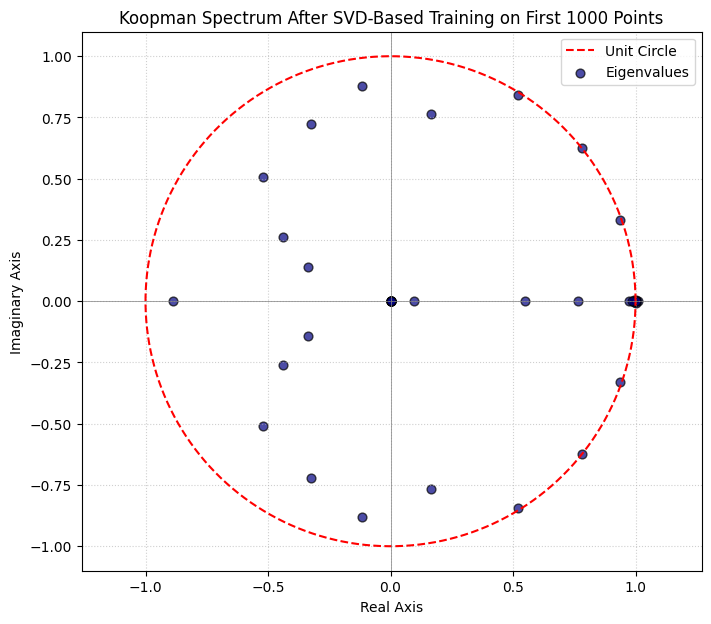

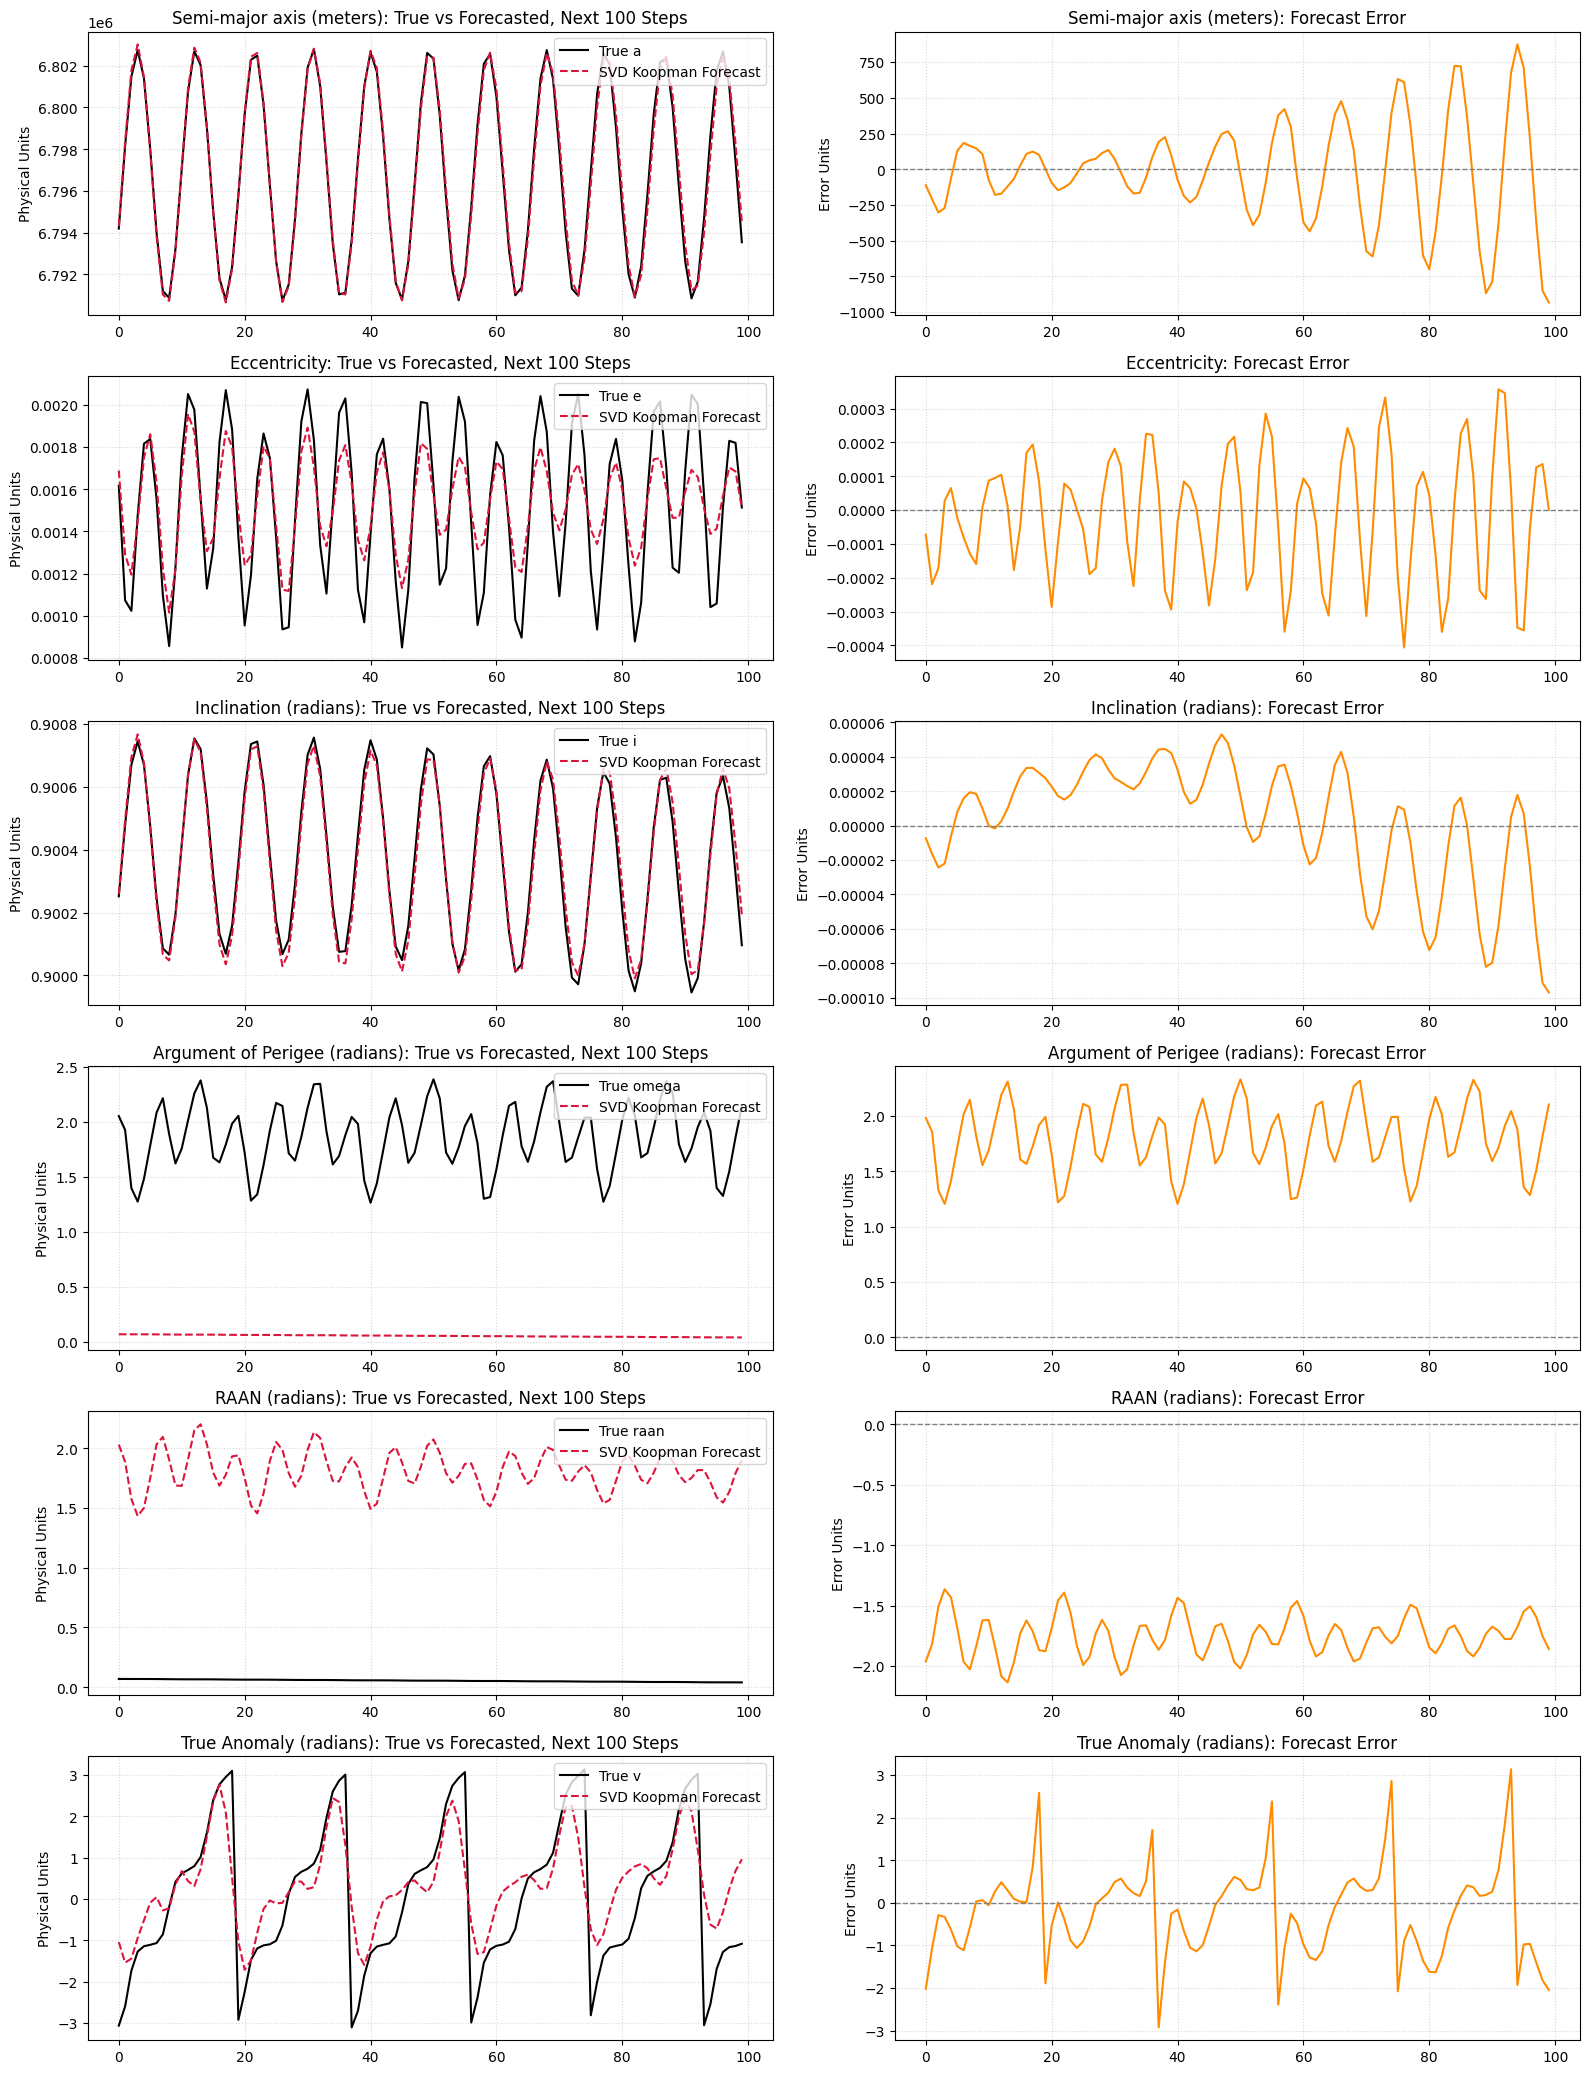

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ==============================================================================
# 1. DATA LOADING
# ==============================================================================

try:
    df_raw = pd.read_csv("raw_orbit_data.csv")
    df_lifted = pd.read_csv("lifted_orbit_data.csv")
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"Missing data file: {e}. Ensure both 'raw_orbit_data.csv' and "
        "'lifted_orbit_data.csv' are in your working directory."
    )

Z = df_lifted.values
n_samples, n_dim = Z.shape

print("=== DATA SETUP ===")
print(f"Loaded lifted states shape: {Z.shape}")
print(f"Total time steps: {n_samples}")
print(f"Total lifted dimensions: {n_dim}\n")


# ==============================================================================
# 2. SETTINGS: TRAIN FIRST 1000, PREDICT NEXT 100
# ==============================================================================

N_train = 1000
N_forecast = 100

if n_samples < N_train + N_forecast:
    raise ValueError(
        f"Not enough data. You need at least {N_train + N_forecast} samples, "
        f"but you only have {n_samples}."
    )


# ==============================================================================
# 3. SCALER FOR INVERSE TRANSFORM
# ==============================================================================

# IMPORTANT:
# This scaler must be fitted in the SAME WAY as in your lifting code.
# If your lifting code used all raw data, use df_raw[['a', 'e']].
# If your lifting code used only training data, use df_raw.iloc[:N_train][['a', 'e']].

scaler_ae = MinMaxScaler(feature_range=(-1, 1))
scaler_ae.fit(df_raw[['a', 'e']])

# For cleaner train/test protocol, you may instead use:
# scaler_ae.fit(df_raw.iloc[:N_train][['a', 'e']])


# ==============================================================================
# 4. SPLIT DATA
# ==============================================================================

# First 1000 lifted states are used for EDMD training
Z_train = Z[:N_train]

# The next 100 lifted states are kept only for comparison
Z_future_true = Z[N_train:N_train + N_forecast]

# For EDMD, we need pairs:
# Z(k)     -> Z(k+1)
# Z1_train -> Z2_train

Z1_train = Z_train[:-1]
Z2_train = Z_train[1:]

print("=== TRAIN / FORECAST SPLIT ===")
print(f"Z_train shape: {Z_train.shape}")
print(f"Z1_train shape: {Z1_train.shape}")
print(f"Z2_train shape: {Z2_train.shape}")
print(f"Z_future_true shape: {Z_future_true.shape}\n")


# ==============================================================================
# 5. TRAIN KOOPMAN OPERATOR USING SVD-BASED EDMD
# ==============================================================================

# We want to learn:
#
#     Z1_train @ A ≈ Z2_train
#
# where:
#
#     z(k+1) = z(k) @ A
#
# Since our lifted states are row vectors, A is the row-vector Koopman operator.
#
# Using SVD:
#
#     Z1_train = U S V^T
#     Z1_train^+ = V S^+ U^T
#     A = Z1_train^+ Z2_train

X = Z1_train
Y = Z2_train

# Singular Value Decomposition
U, S, Vt = np.linalg.svd(X, full_matrices=False)

# ------------------------------------------------------------------------------
# Truncated SVD tolerance
# ------------------------------------------------------------------------------

# Relative tolerance: keep singular values larger than rcond * largest singular value
rcond = 1e-10
svd_tol = rcond * S[0]

rank = np.sum(S > svd_tol)

U_r = U[:, :rank]
S_r = S[:rank]
Vt_r = Vt[:rank, :]

print("=== SVD-BASED KOOPMAN TRAINING ===")
print(f"Original lifted dimension: {n_dim}")
print(f"Number of singular values: {len(S)}")
print(f"Largest singular value: {S[0]:.6e}")
print(f"SVD tolerance: {svd_tol:.6e}")
print(f"Retained SVD rank: {rank}")

# Compute pseudoinverse using truncated SVD
X_pinv = Vt_r.T @ np.diag(1.0 / S_r) @ U_r.T

# Row-vector Koopman operator
A = X_pinv @ Y

# To keep the rest of your old code unchanged:
#
# Old sklearn Ridge convention:
#     z_next = z_current @ K.T
#
# Here:
#     z_next = z_current @ A
#
# Therefore:
#     K.T = A
#     K = A.T

K = A.T

print(f"Koopman operator K shape: {K.shape}\n")


# ==============================================================================
# 6. RECURSIVE FORECASTING FOR NEXT 100 STEPS
# ==============================================================================

# Start from the last known training state:
# This is Z at time index 999.

z_current = Z_train[-1].copy()

Z_forecast = []

for step in range(N_forecast):

    # Predict next lifted state:
    #
    # z(k+1) = z(k) @ A
    #
    # Since K = A.T, this is equivalent to:
    #
    # z_next = z_current @ K.T

    z_next = z_current @ K.T

    Z_forecast.append(z_next)

    # Use prediction as the next input
    z_current = z_next.copy()

Z_forecast = np.array(Z_forecast)

print("=== FORECASTING ===")
print(f"Z_forecast shape: {Z_forecast.shape}")
print("Forecasted time indices:")
print(f"From raw index {N_train} to {N_train + N_forecast - 1}\n")


# ==============================================================================
# 7. UNLIFT FORECASTED VALUES TO RAW ORBITAL ELEMENTS
# ==============================================================================

# True raw values for the future 100 steps
true_raw_future = df_raw.iloc[N_train:N_train + N_forecast].copy().reset_index(drop=True)

# Your convention:
# column 0 of lifted data is probably constant 1
# columns 1:7 are:
# ['a', 'e', 'i', 'omega', 'raan', 'v']
#
# Important:
# This assumes your lifted data keeps the original six states in columns 1 to 6.
# If your lifted data has a different column ordering, change this part.

pred_raw_future = pd.DataFrame(
    Z_forecast[:, 1:7],
    columns=['a', 'e', 'i', 'omega', 'raan', 'v']
)

# Inverse transform a and e
pred_raw_future[['a', 'e']] = scaler_ae.inverse_transform(
    pred_raw_future[['a', 'e']]
)

angles = ['i', 'omega', 'raan', 'v']


# ==============================================================================
# 8. COMPUTE ERRORS
# ==============================================================================

errors = pd.DataFrame()

for col in ['a', 'e', 'i', 'omega', 'raan', 'v']:

    true_vals = true_raw_future[col].values
    pred_vals = pred_raw_future[col].values

    if col in angles:
        # Angle-aware error
        #
        # This avoids problems near 0 and 2*pi.
        #
        # Example:
        # true angle = 0.01
        # predicted angle = 6.27
        #
        # Simple subtraction gives a large error,
        # but physically the angles are close.

        errors[col] = np.arctan2(
            np.sin(true_vals - pred_vals),
            np.cos(true_vals - pred_vals)
        )

    else:
        errors[col] = true_vals - pred_vals


print("=== ERROR SUMMARY FOR NEXT 100 FORECASTED STEPS ===")

for col in ['a', 'e', 'i', 'omega', 'raan', 'v']:

    rmse = np.sqrt(np.mean(errors[col].values ** 2))
    mae = np.mean(np.abs(errors[col].values))

    print(f"{col}:")
    print(f"  RMSE = {rmse:.6e}")
    print(f"  MAE  = {mae:.6e}")

print()


# ==============================================================================
# 9. OPTIONAL: KOOPMAN SPECTRUM
# ==============================================================================

eigvals, _ = np.linalg.eig(K)

magnitudes = np.abs(eigvals)
max_idx = np.argmax(magnitudes)
max_eigval = eigvals[max_idx]
max_magnitude = magnitudes[max_idx]

print("=== KOOPMAN SPECTRUM ANALYSIS ===")
print(f"Total Eigenvalues: {len(eigvals)}")
print(f"Max Eigenvalue: {max_eigval.real:.5f} + {max_eigval.imag:.5f}j")
print(f"Max Eigenvalue Magnitude: {max_magnitude:.5f}")

plt.figure(figsize=(8, 7))

theta = np.linspace(0, 2 * np.pi, 200)

plt.plot(
    np.cos(theta),
    np.sin(theta),
    'r--',
    linewidth=1.5,
    label='Unit Circle'
)

plt.scatter(
    eigvals.real,
    eigvals.imag,
    color='navy',
    alpha=0.7,
    edgecolors='k',
    s=40,
    label='Eigenvalues'
)

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

plt.title("Koopman Spectrum After SVD-Based Training on First 1000 Points")
plt.xlabel("Real Axis")
plt.ylabel("Imaginary Axis")
plt.axis("equal")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()


# ==============================================================================
# 10. PLOT TRUE VS FORECASTED NEXT 100 STEPS
# ==============================================================================

feature_names = {
    'a': 'Semi-major axis (meters)',
    'e': 'Eccentricity',
    'i': 'Inclination (radians)',
    'omega': 'Argument of Perigee (radians)',
    'raan': 'RAAN (radians)',
    'v': 'True Anomaly (radians)'
}

fig, axes = plt.subplots(
    len(feature_names),
    2,
    figsize=(16, 3.5 * len(feature_names))
)

for idx, col in enumerate(feature_names.keys()):

    name = feature_names[col]

    true_vals = true_raw_future[col].values
    pred_vals = pred_raw_future[col].values
    error_vals = errors[col].values

    # Left: True vs Forecasted
    ax_comp = axes[idx, 0]

    ax_comp.plot(
        true_vals,
        label=f"True {col}",
        color="black",
        linewidth=1.5
    )

    ax_comp.plot(
        pred_vals,
        "--",
        label="SVD Koopman Forecast",
        color="crimson",
        linewidth=1.5
    )

    ax_comp.set_title(f"{name}: True vs Forecasted, Next 100 Steps")
    ax_comp.set_ylabel("Physical Units")
    ax_comp.grid(True, linestyle=":", alpha=0.5)
    ax_comp.legend(loc="upper right")

    # Right: Error
    ax_err = axes[idx, 1]

    ax_err.plot(
        error_vals,
        color="darkorange",
        linewidth=1.5
    )

    ax_err.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1
    )

    ax_err.set_title(f"{name}: Forecast Error")
    ax_err.set_ylabel("Error Units")
    ax_err.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

